# Student Performance Indicator

#### Life cycle of Machine learning Project:

+ Understanding the Problem Statement
+ Data Collection
+ Data Checks to perform
+ Exploratory data analysis
+ Data Pre-Processing
+ Model Training
+ Choose best model

### 1) Problem statement
This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity,
Parental level of education, Lunch and Test preparation course.

### 2) Data Collection
+ Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetld=74977
+ The data consists of 8 column and 1000 rows.

### 2.1) Import Data and Required Packages

*Note the data is imported here with the assumption the data set is available in ./data directory and does not use a complex data ingestion method*

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data import:

In [39]:
df = pd.read_csv("data/StudentsPerformance.csv")

In [40]:
# top 5 records:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [41]:
print(f'Shape of the dataset: {df.shape}')

Shape of the dataset: (1000, 8)


### 2.2) Dataset Information:

+ gender : sex of students -> (Male/female)
+ race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
+ parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high
school)
+ lunch : having lunch before test (standard or free/reduced)
+ test preparation course : complete or not complete before test
+ math score
+ reading score
+ writing score

## 3) Data Checks to perform

+ Check Missing values
+ Check Duplicates
+ Check data type
+ Check the number of unique values of each column
+ Check statistics of data set
+ Check various categories present in the different categorical column

In [42]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

**No Missing Values**

In [43]:
df.duplicated().sum()

np.int64(0)

**No Duplicate Values**

In [44]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [45]:
print("Unique Entries:")
df.nunique()

Unique Entries:


gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [46]:
print("Statistics of Dataset:")
df.describe()

Statistics of Dataset:


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


+ From above description of numerical data, all means are very close to each other - between 66 and 68.05;
+ All standard deviations are also close between 14.6 and 15.19;
+ While there is a minimum score 0 for math, for writing minimum is much higher = 10 and for reading minimum is higher = 17

In [47]:
# EDA:

num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'Numeric features: {num_features}\n Categorical features: {cat_features}\n ')

Numeric features: ['math score', 'reading score', 'writing score']
 Categorical features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
 


In [48]:
# exploring cat_features:
print("EDA: \n")
for fea in cat_features:
    print(f'Unique categories in "{fea}" are:')
    print(df[fea].unique(),"\n")

EDA: 

Unique categories in "gender" are:
['female' 'male'] 

Unique categories in "race/ethnicity" are:
['group B' 'group C' 'group A' 'group D' 'group E'] 

Unique categories in "parental level of education" are:
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school'] 

Unique categories in "lunch" are:
['standard' 'free/reduced'] 

Unique categories in "test preparation course" are:
['none' 'completed'] 



In [49]:
# exploring num_features:
num_features

['math score', 'reading score', 'writing score']

**Adding Columns: 'Total Score' & 'Average'**

In [ ]:
cols = ['math score', 'reading score', 'writing score']

df['total_score'] = df[cols].sum(axis=1)
df['average'] = df[cols].mean(axis=1)

#OPTIMAL WAY:
# cols = ['math score', 'reading score', 'writing score']

# df = df.assign(
#     total_score=df[cols].sum(axis=1),
#     average=df[cols].mean(axis=1)
# )

In [51]:
print('Updated Dataset: ')
df.head()

Updated Dataset: 


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [53]:
# reading_full = df[df['reading score']==100]['average'].count()
# writing_full = df[df['writing score']==100]['average'].count()
# math_full = df[df['math score']==100]['average'].count()

reading_full = (df['reading score'] == 100).sum()
writing_full = (df['writing score'] == 100).sum()
math_full = (df['math score'] == 100).sum()

print(f'Number of students with full marks in Reading: {reading_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Maths: {math_full}')

Number of students with full marks in Reading: 17
Number of students with full marks in Writing: 14
Number of students with full marks in Maths: 7


In [70]:

reading_less_20 = (df['reading score'] <= 20).sum()
writing_less_20 = (df['writing score'] <= 20).sum()
math_less_20 = (df['math score'] <= 20).sum()
print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


**Insights**
+ From above values we get students have performed the worst in Maths
+ Best performance is in reading section


## 4) ED (Visualization)

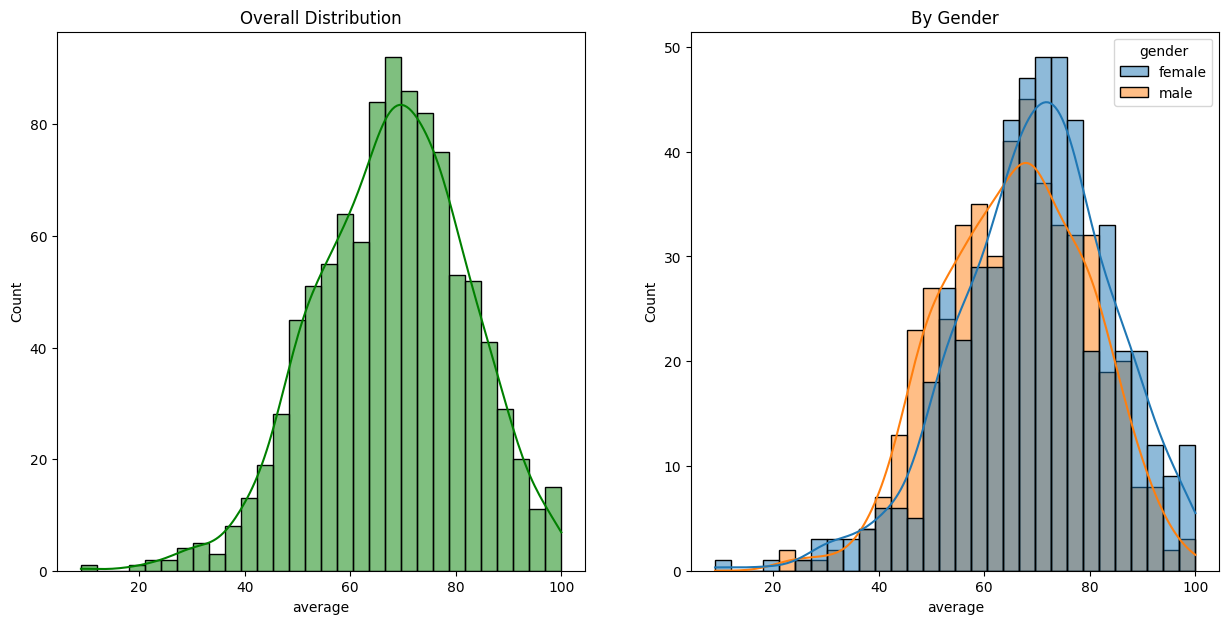

In [ ]:
# Gender based classification
fig, axs = plt.subplots(1,2,figsize = (15,7))
plt.subplot(121)
sns.histplot(df,x='average',bins = 30, kde=True, color='g')

plt.subplot(122)
sns.histplot(df,x='average',bins = 30, kde=True, hue='gender')
axs[0].set_title("Overall Distribution")
axs[1].set_title("By Gender")

plt.show()

# or
# fig, axs = plt.subplots(1, 2, figsize=(15, 7))

# sns.histplot(df, x='average', bins=40, kde=True, color='g', ax=axs[0])
# sns.histplot(df, x='average', bins=40, kde=True, hue='gender', ax=axs[1])

# plt.show()

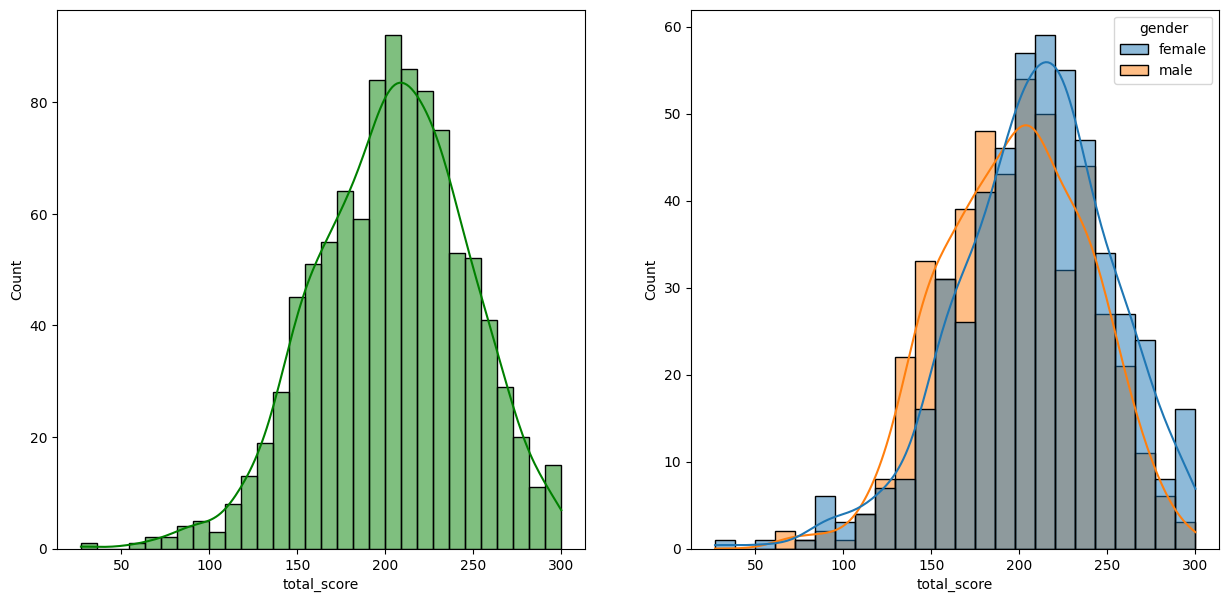

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='total_score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='total_score',kde=True,hue='gender')
plt.show()

**Female Students outperforms male students**

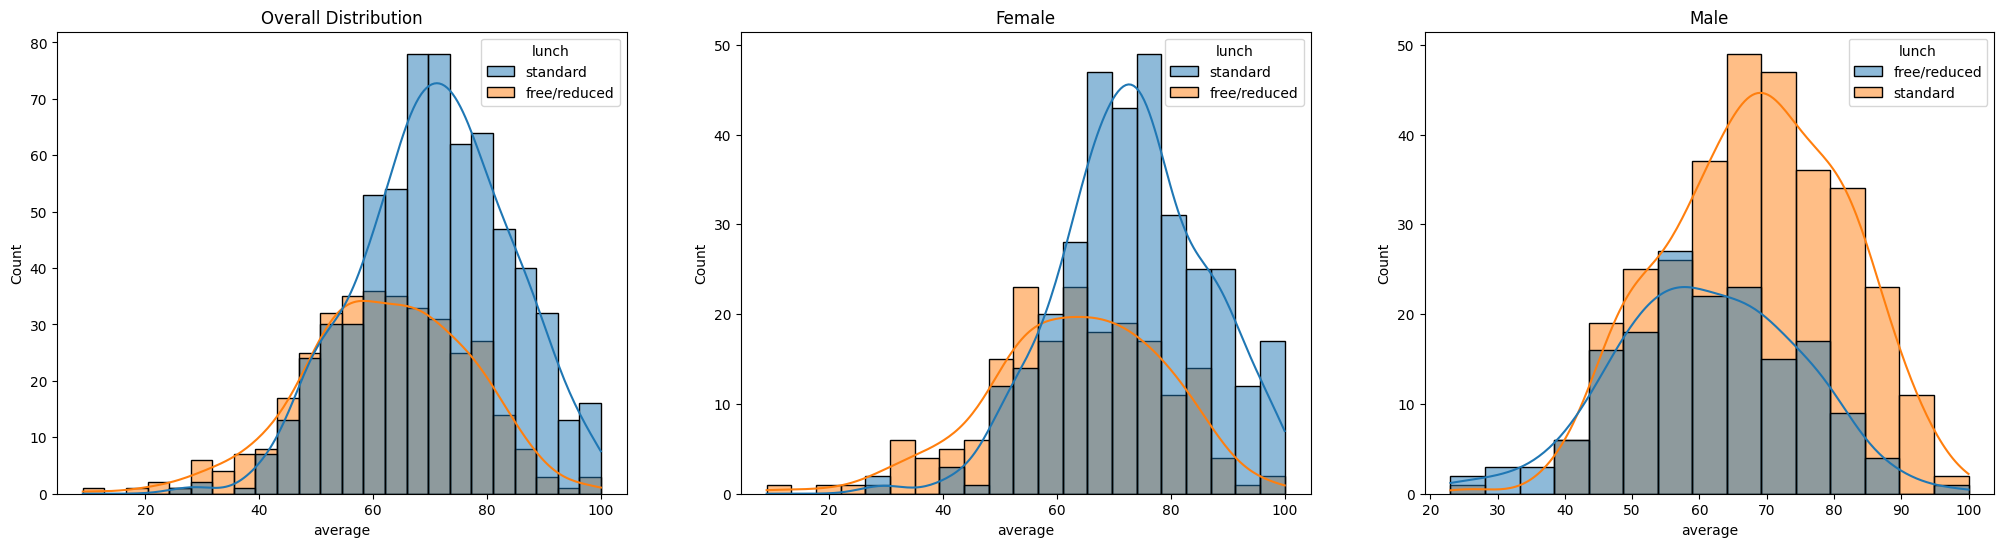

In [ ]:
# Lunch Based

fig, axs = plt.subplots(1, 3, figsize=(25, 6))

sns.histplot(df, x='average', kde=True, hue='lunch', ax=axs[0])
sns.histplot(df[df.gender=='female'], x='average', kde=True, hue='lunch', ax=axs[1])
sns.histplot(df[df.gender=='male'], x='average', kde=True, hue='lunch', ax=axs[2])
axs[0].set_title("Overall Distribution")
axs[1].set_title("Female")
axs[2].set_title("Male")

plt.show()

**Insights**
+ Standard lunch helps perform well in exams.
+ Standard lunch helps perform well in exams be it a male or a female.

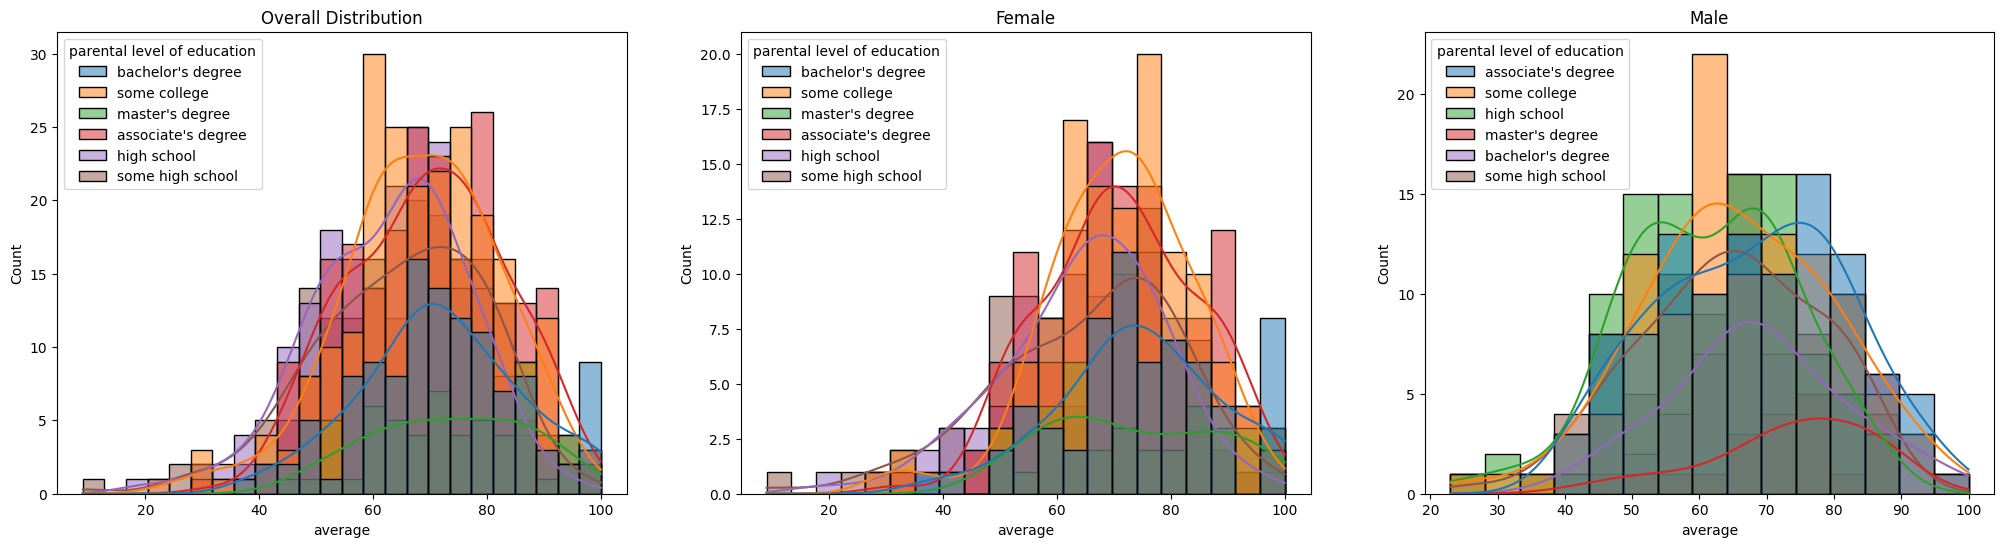

In [77]:
# Parental Education affect

fig, axs = plt.subplots(1, 3, figsize=(25, 6))

sns.histplot(df, x='average', kde=True, hue='parental level of education', ax=axs[0])
sns.histplot(df[df.gender=='female'], x='average', kde=True, hue='parental level of education', ax=axs[1])
sns.histplot(df[df.gender=='male'], x='average', kde=True, hue='parental level of education', ax=axs[2])
axs[0].set_title("Overall Distribution")
axs[1].set_title("Female")
axs[2].set_title("Male")

plt.show()

**Insights**
- In general parent's education don't help student perform well in exam.
- 2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam
- 3rd plot we can see there is no effect of parent's education on female students.

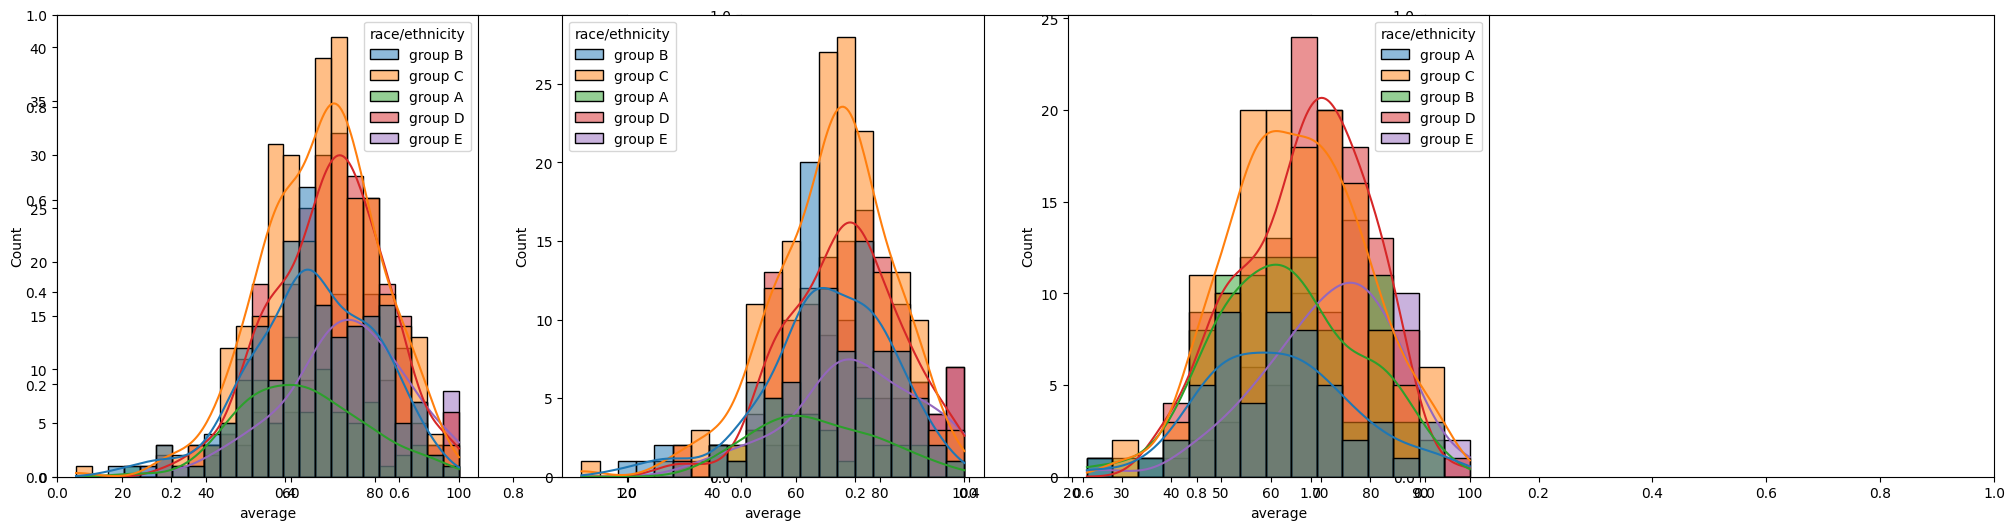

In [78]:
# Race/ ethnicity affect:

plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
ax =sns.histplot(data=df,x='average',kde=True,hue='race/ethnicity')
plt.subplot(142)
ax =sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='race/ethnicity')
plt.subplot(143)
ax =sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='race/ethnicity')
plt.show()

**Insights**
- Students of group A and group B tends to perform poorly in exam.
- Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female

#### 4.2 Maximum score of students in all three subjects

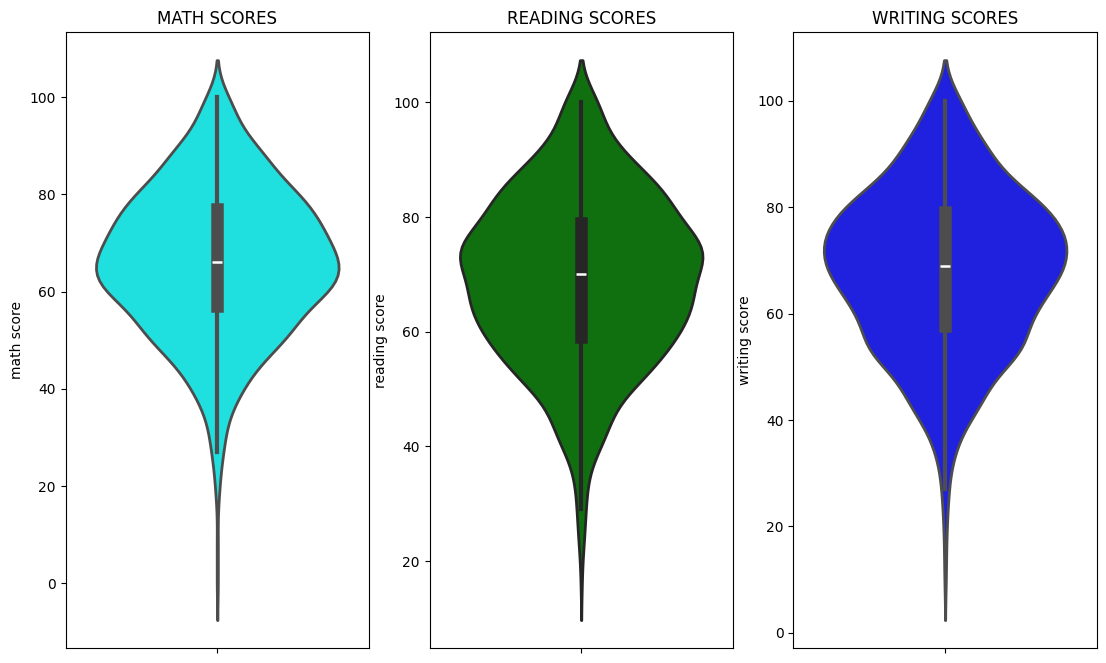

In [88]:

plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math score',data=df,color='cyan',linewidth=2)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading score',data=df,color='green',linewidth=2)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing score',data=df,color='blue',linewidth=2)
plt.show()

**Insights**
- From the above three plots its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing most of them score from 50-80

#### 4.3 Multivariate analysis using pieplot

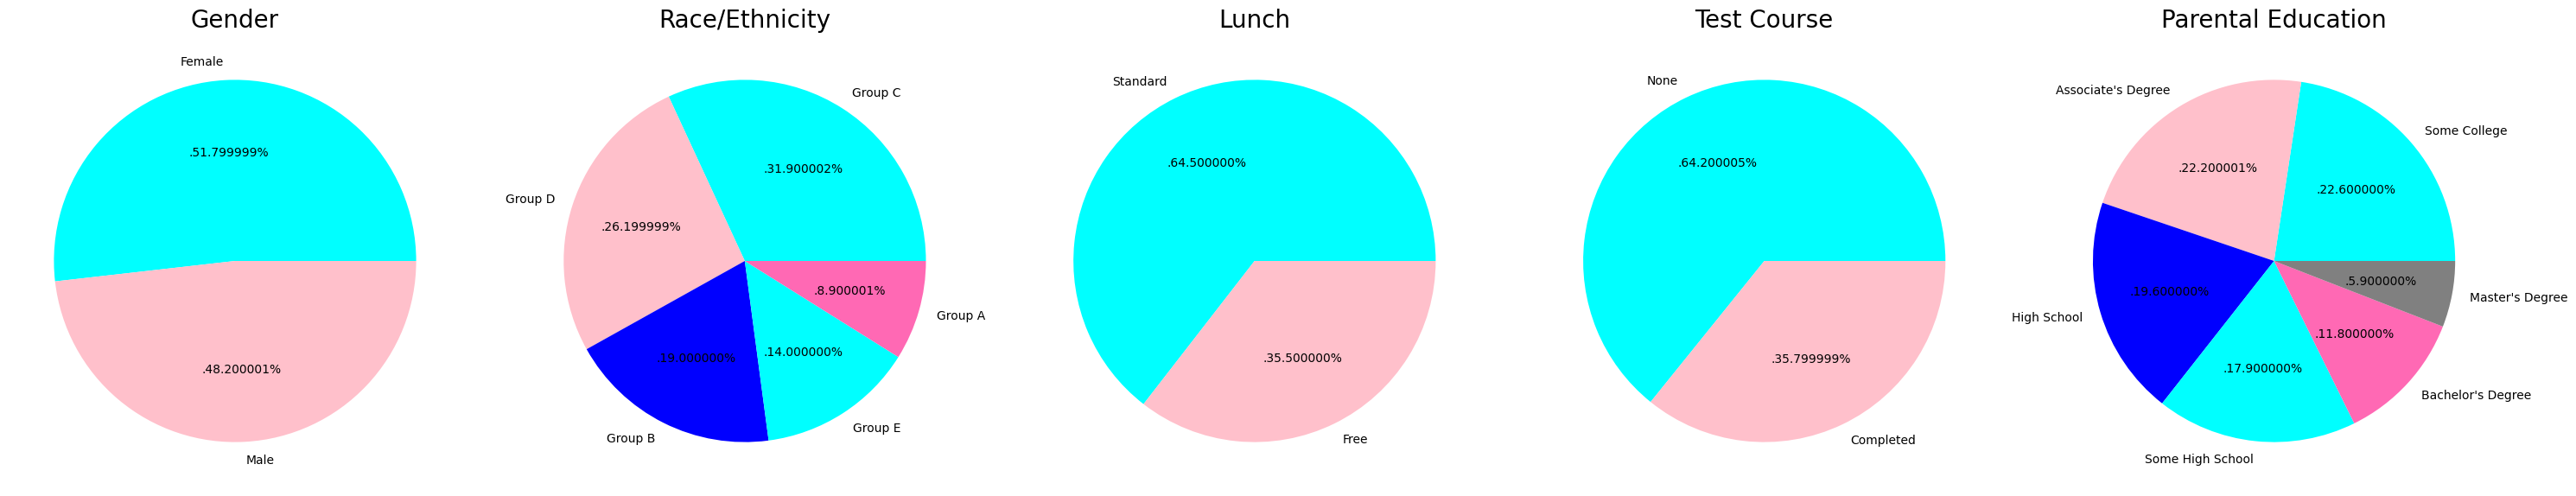

In [96]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['cyan','pink']

plt.pie(size, colors = color, labels = labels,autopct = '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 2)
size = df['race/ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['cyan','pink', 'blue', 'cyan','hotpink']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Race/Ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['cyan','pink']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 4)
size = df['test preparation course'].value_counts()
labels = 'None', 'Completed'
color = ['cyan','pink']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = df['parental level of education'].value_counts()
labels =  'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['cyan','pink', 'blue', 'cyan','hotpink','grey']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

#### 4.4 Feature Wise Visualization
#### 4.4.1 GENDER COLUMN
- How is distribution of Gender ?
- Is gender has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( How is distribution of Gender ? )

C:\Users\ASUS\AppData\Local\Temp\ipykernel_38032\2720778079.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)


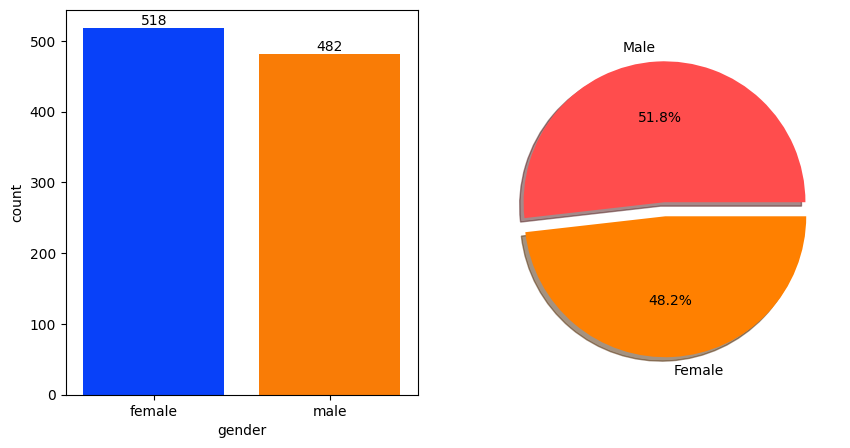

In [102]:
f,ax=plt.subplots(1,2,figsize=(10,5))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=10)

plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

#### Insights 
- Gender has balanced data with female students are 518 (48%) and male students are 482 (52%) 

#### BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? ) 

In [110]:
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group

,math score,reading score,writing score,total_score,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


C:\Users\ASUS\AppData\Local\Temp\ipykernel_38032\2222181969.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  female_scores = [gender_group['average'][0], gender_group['math score'][0]]
C:\Users\ASUS\AppData\Local\Temp\ipykernel_38032\2222181969.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  male_scores = [gender_group['average'][1], gender_group['math score'][1]]


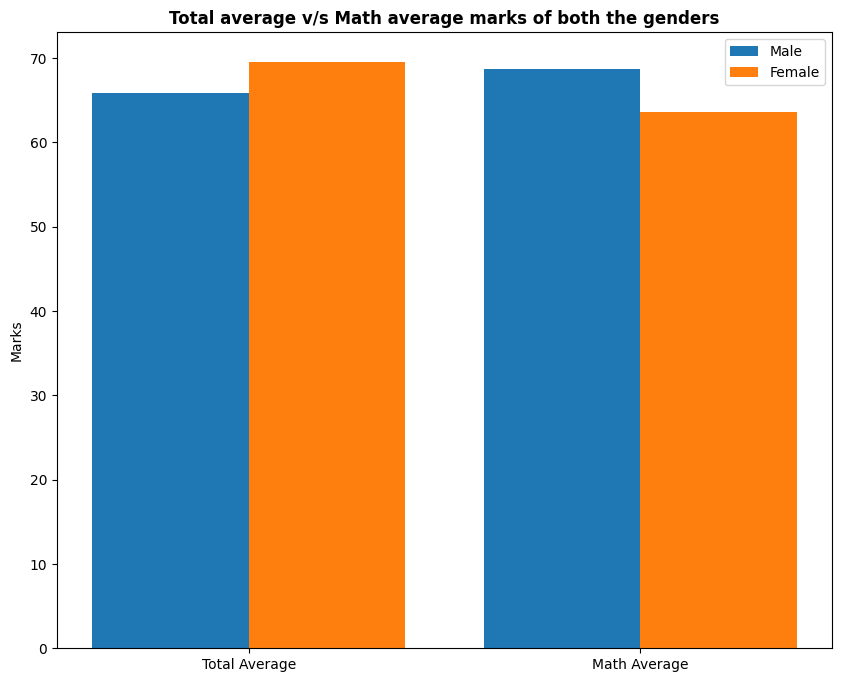

In [ ]:
plt.figure(figsize=(10, 8))

X = ['Total Average','Math Average']


female_scores = [gender_group['average'][0], gender_group['math score'][0]]
male_scores = [gender_group['average'][1], gender_group['math score'][1]]

X_axis = np.arange(len(X))

plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')

plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()

#### Insights 
- On an average females have a better overall score than men.
- whereas males have scored higher in Maths.

#### 4.4.2 RACE/EHNICITY COLUMN
- How is Group wise distribution ?
- Is Race/Ehnicity has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

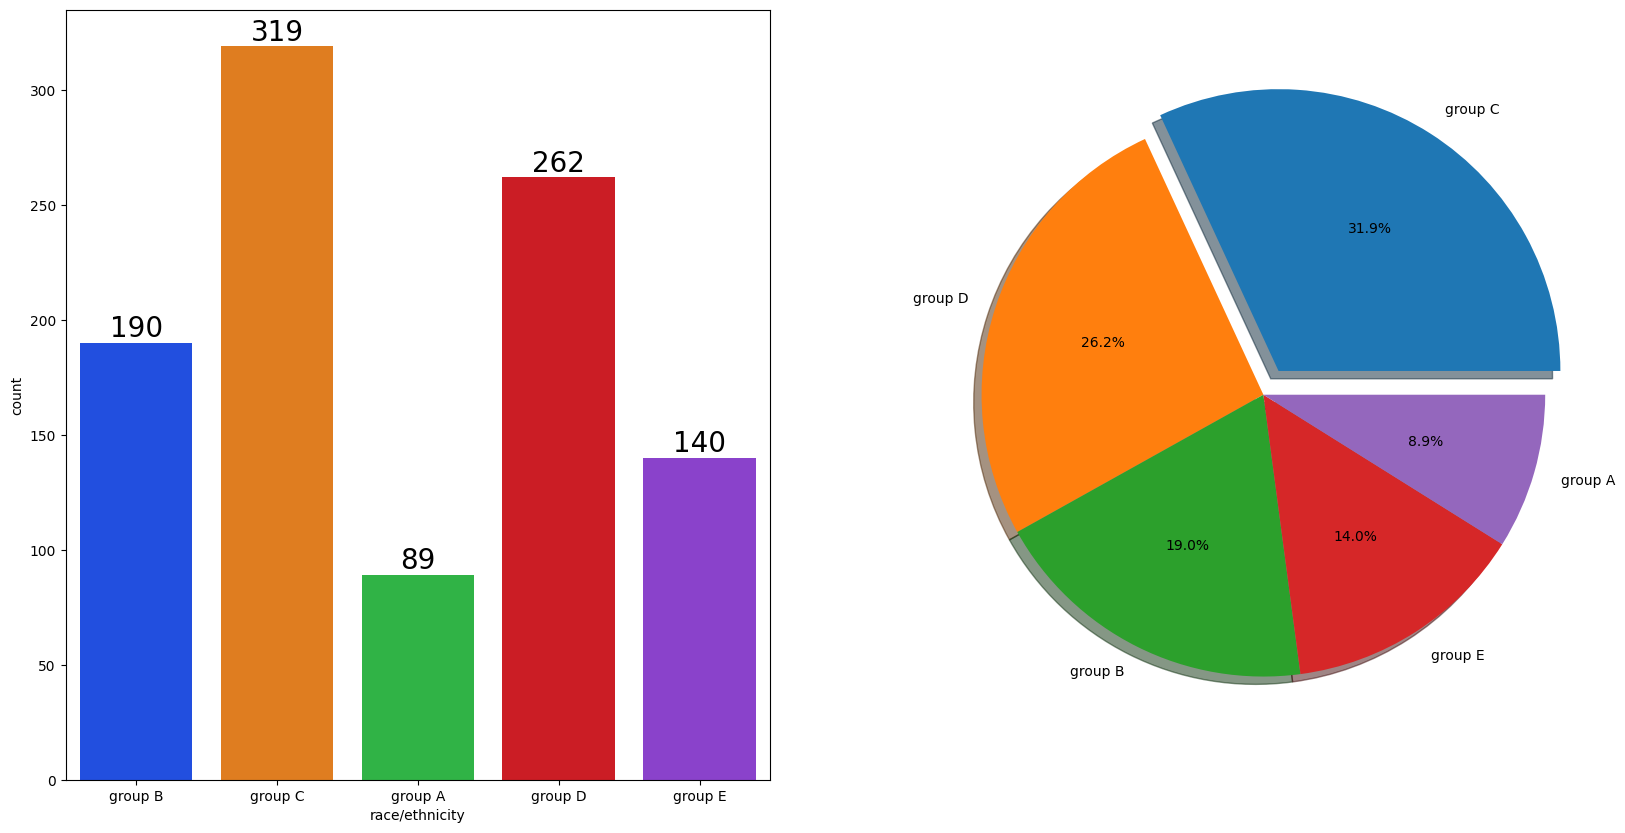

In [114]:
f,ax=plt.subplots(1,2,figsize=(20,10))
# sns.countplot(x=df['race/ethnicity'],data=df,palette = 'bright',ax=ax[0],saturation=0.95)
sns.countplot(
    x='race/ethnicity',
    data=df,
    hue='race/ethnicity',
    palette='bright',
    legend=False,
    ax=ax[0]
)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)

# plt.pie(x = df['race/ethnicity'].value_counts(),labels=df['race/ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True)
ax[1].pie(
    df['race/ethnicity'].value_counts(),
    labels=df['race/ethnicity'].value_counts().index,
    explode=[0.1,0,0,0,0],
    autopct='%1.1f%%',
    shadow=True
)
plt.show()

#### Insights 
- Most of the student belonging from group C /group D.
- Lowest number of students belong to groupA.

#### BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

C:\Users\ASUS\AppData\Local\Temp\ipykernel_38032\3979719510.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Group_data2['math score'].mean().index,y=Group_data2['math score'].mean().values,palette = 'mako',ax=ax[0])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_38032\3979719510.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Group_data2['reading score'].mean().index,y=Group_data2['reading score'].mean().values,palette = 'flare',ax=ax[1])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_38032\3979719510.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect

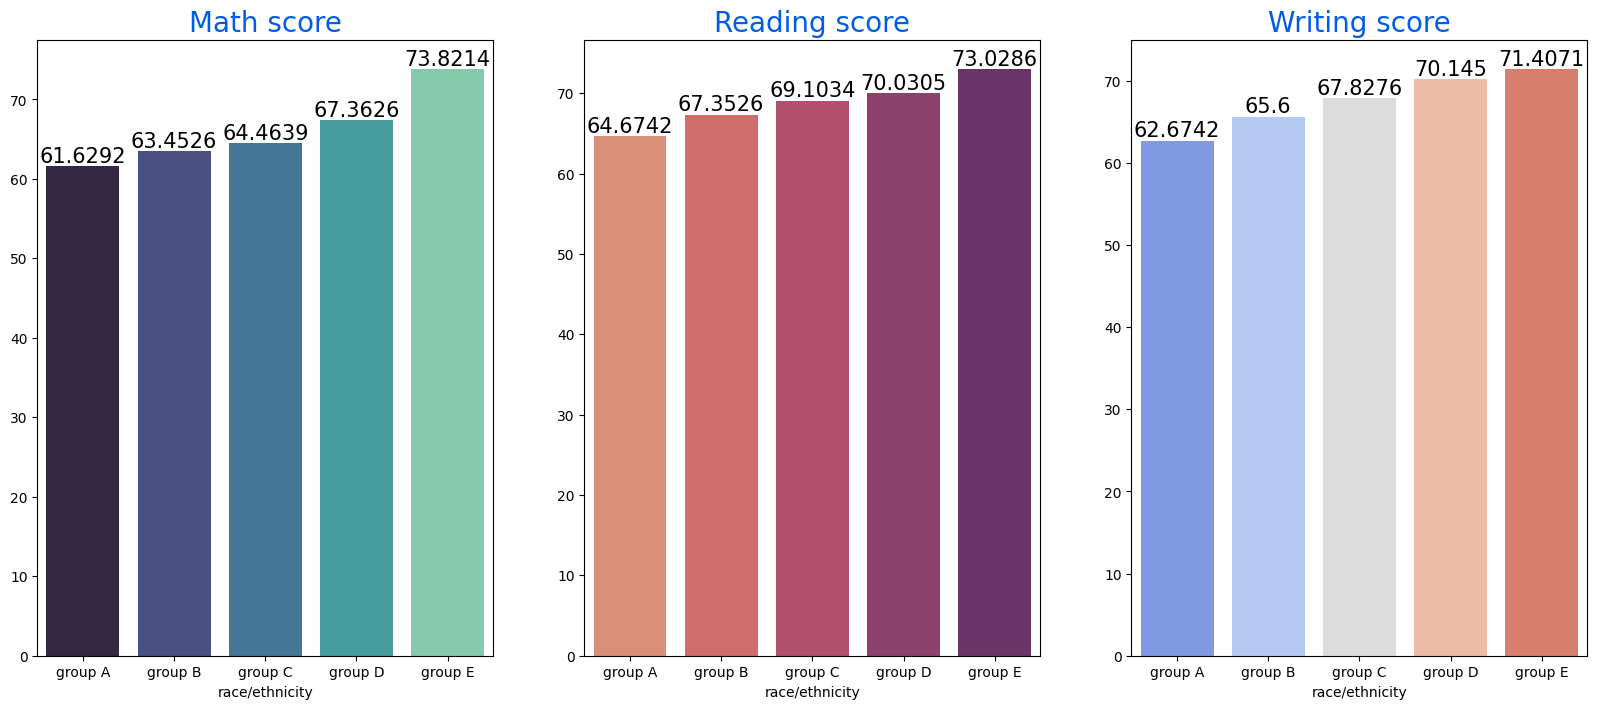

In [115]:
Group_data2=df.groupby('race/ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math score'].mean().index,y=Group_data2['math score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading score'].mean().index,y=Group_data2['reading score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing score'].mean().index,y=Group_data2['writing score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

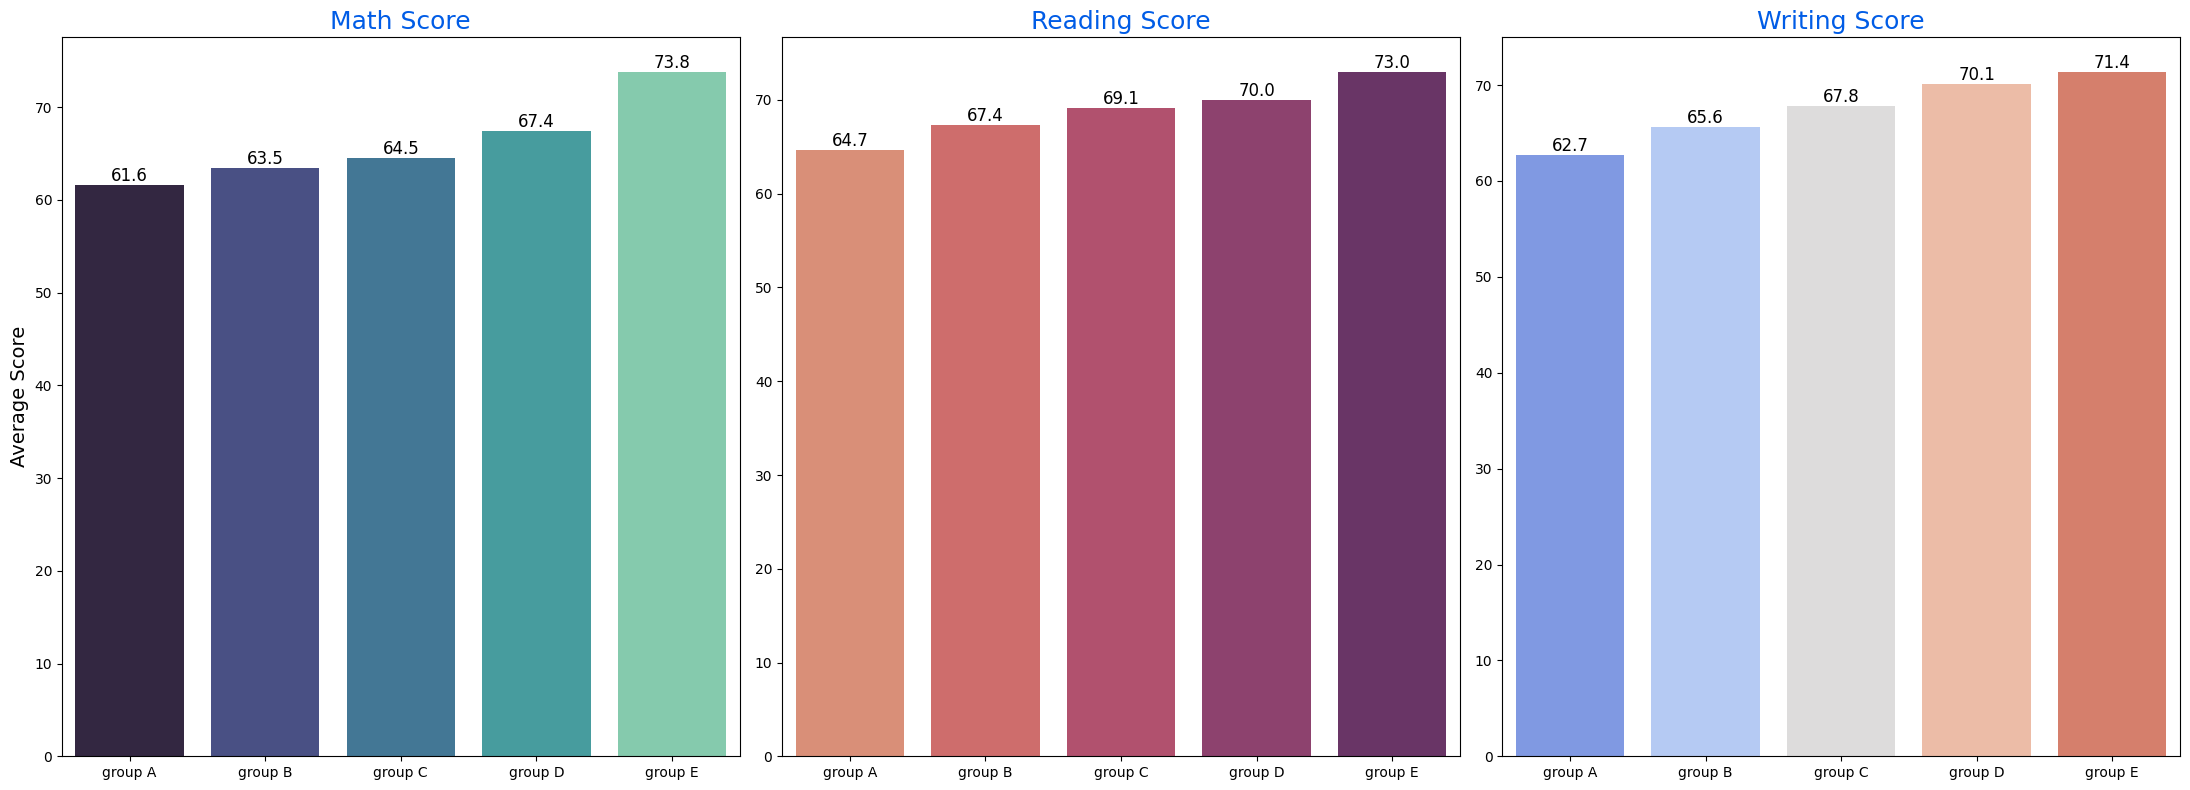

In [118]:
math_mean = df.groupby('race/ethnicity')['math score'].mean().reset_index()
reading_mean = df.groupby('race/ethnicity')['reading score'].mean().reset_index()
writing_mean = df.groupby('race/ethnicity')['writing score'].mean().reset_index()

# Set up subplots
f, ax = plt.subplots(1, 3, figsize=(22, 8))

# Plot Math scores
sns.barplot(
    data=math_mean,
    x='race/ethnicity',
    y='math score',
    hue='race/ethnicity',  # assigns palette correctly
    palette='mako',
    dodge=False,  # no duplicated bars
    ax=ax[0]
)
ax[0].set_title('Math Score', fontsize=18, color='#005ce6')
ax[0].set_xlabel('')
ax[0].set_ylabel('Average Score', fontsize=14)

# Add bar labels
for container in ax[0].containers:
    ax[0].bar_label(container, fmt='%.1f', color='black', fontsize=12)

# Plot Reading scores
sns.barplot(
    data=reading_mean,
    x='race/ethnicity',
    y='reading score',
    hue='race/ethnicity',
    palette='flare',
    dodge=False,
    ax=ax[1]
)
ax[1].set_title('Reading Score', fontsize=18, color='#005ce6')
ax[1].set_xlabel('')
ax[1].set_ylabel('')

for container in ax[1].containers:
    ax[1].bar_label(container, fmt='%.1f', color='black', fontsize=12)

# Plot Writing scores
sns.barplot(
    data=writing_mean,
    x='race/ethnicity',
    y='writing score',
    hue='race/ethnicity',
    palette='coolwarm',
    dodge=False,
    ax=ax[2]
)
ax[2].set_title('Writing Score', fontsize=18, color='#005ce6')
ax[2].set_xlabel('')
ax[2].set_ylabel('')

for container in ax[2].containers:
    ax[2].bar_label(container, fmt='%.1f', color='black', fontsize=12)

# Adjust layout
plt.tight_layout()
plt.show()

#### Insights 
- Group E students have scored the highest marks. 
- Group A students have scored the lowest marks. 
- Students from a lower Socioeconomic status have a lower avg in all course subjects

#### 4.4.3 PARENTAL LEVEL OF EDUCATION COLUMN
- What is educational background of student's parent ?
- Is parental education has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

C:\Users\ASUS\AppData\Local\Temp\ipykernel_38032\2764336993.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df['parental level of education'], palette = 'Blues')


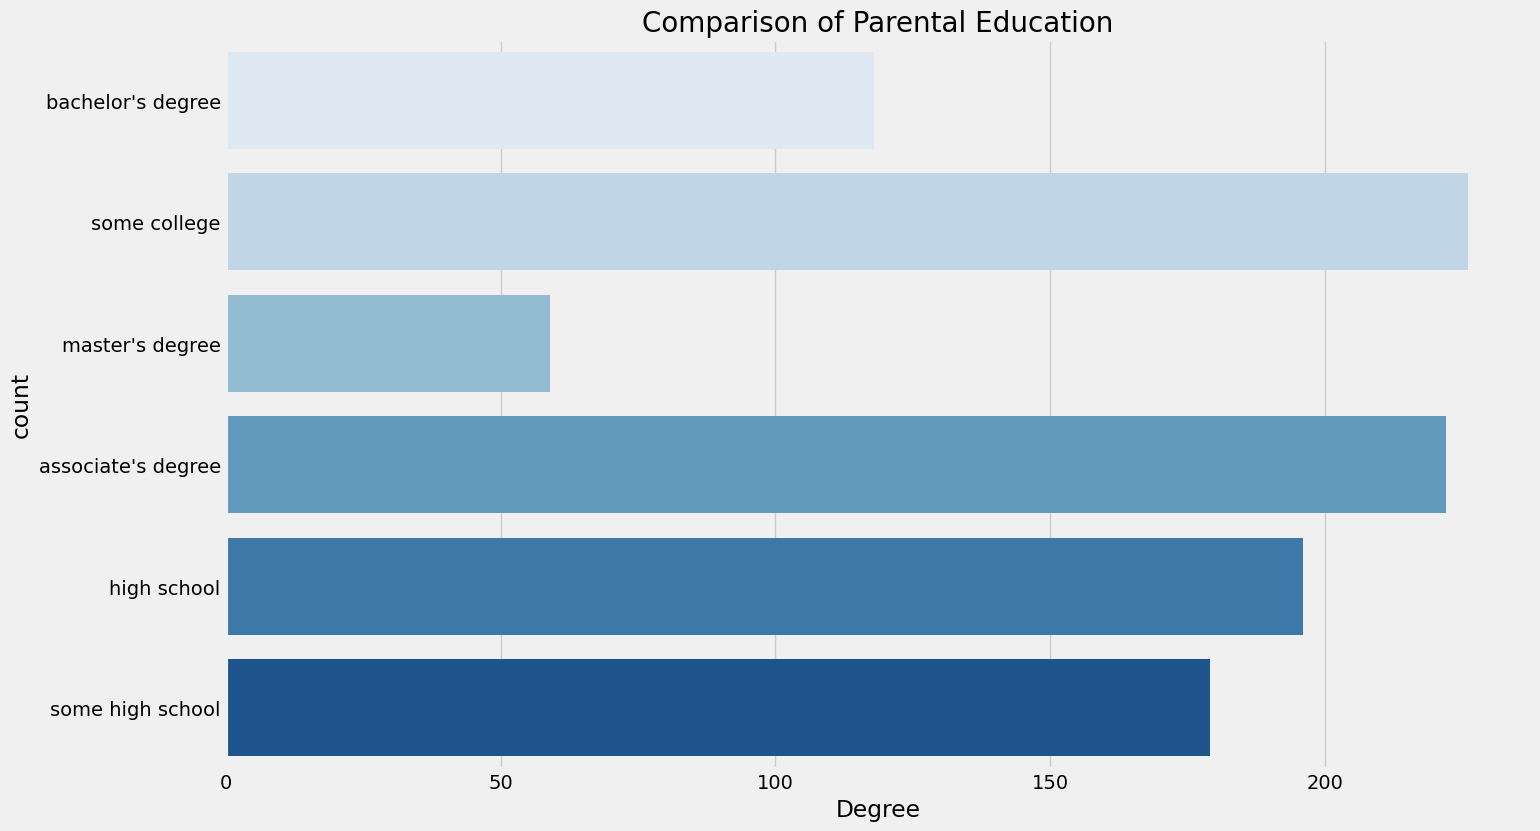

In [126]:
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental level of education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

#### Insights 
- Largest number of parents are from some college.

#### BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

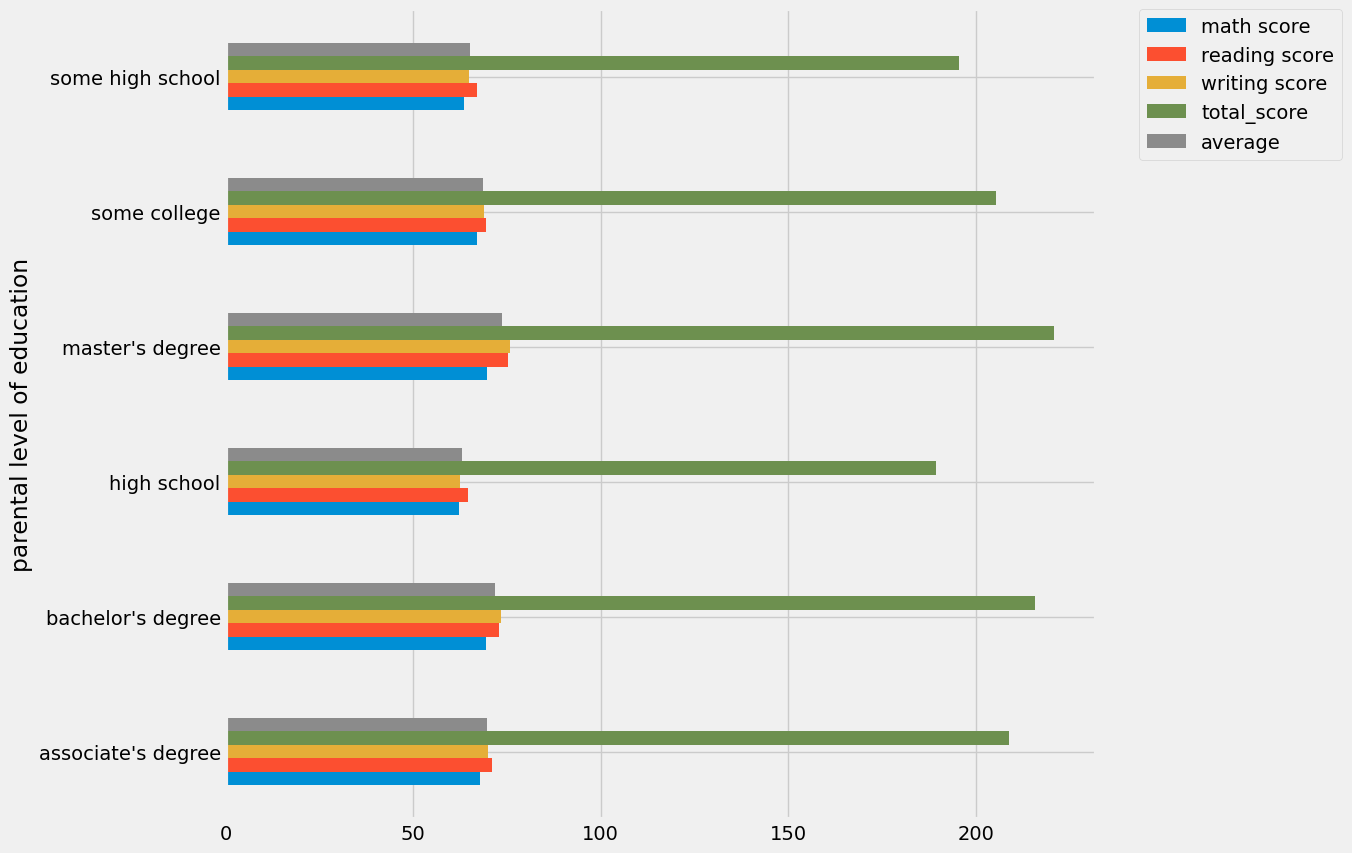

In [ ]:
df.groupby('parental level of education').mean(numeric_only=True).plot(kind='barh',figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

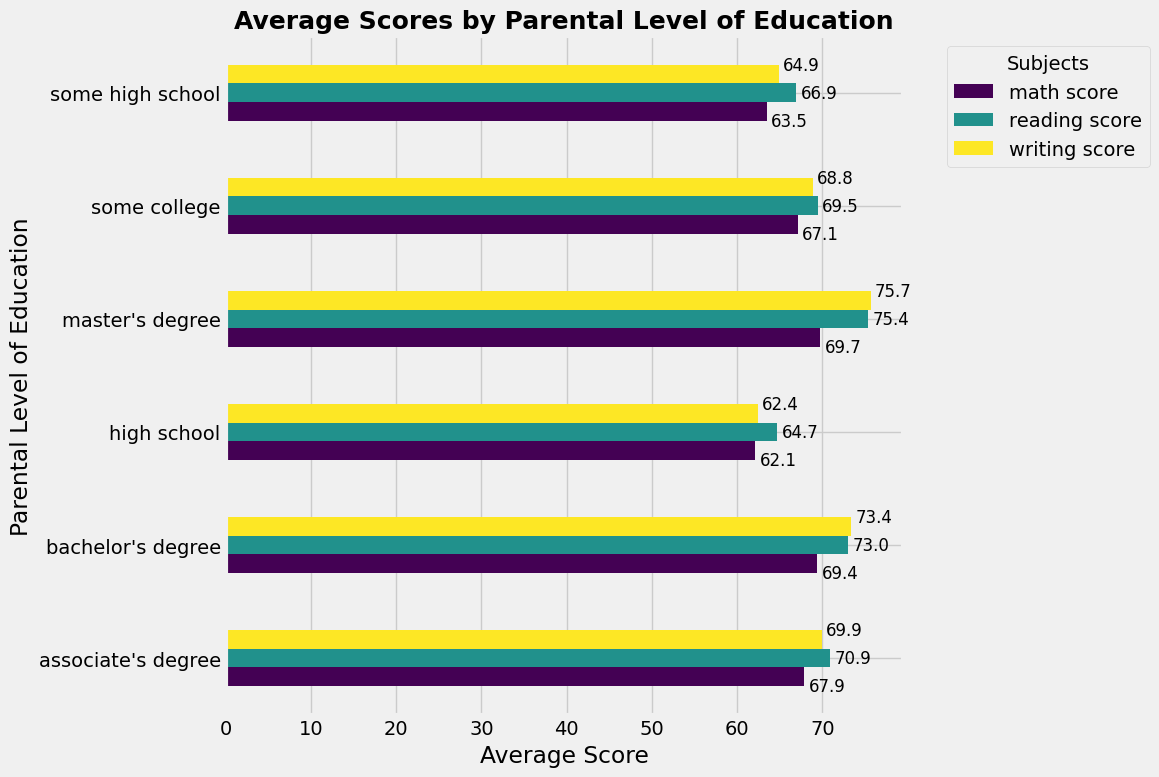

In [129]:
# Select only numeric columns (the scores)
score_cols = ['math score', 'reading score', 'writing score']

# Group by parental education and compute mean of scores
grouped_means = df.groupby('parental level of education')[score_cols].mean()

# Plot horizontal bar chart
ax = grouped_means.plot(kind='barh', figsize=(12,8), colormap='viridis')

plt.title('Average Scores by Parental Level of Education', fontsize=18, fontweight='bold')
plt.xlabel('Average Score')
plt.ylabel('Parental Level of Education')

# Add the values on the bars
for i, row in enumerate(grouped_means.itertuples(index=False)):
    for j, value in enumerate(row):
        ax.text(value + 0.5, i + j*0.25 - 0.25, f'{value:.1f}', color='black', va='center', fontsize=12)

plt.legend(title='Subjects', bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()

#### Insights 
- The score of student whose parents possess master and bachelor level education are higher than others.

#### 4.4.4 LUNCH COLUMN 
- Which type of lunch is most common amoung students ?
- What is the effect of lunch type on test results?


#### UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )

C:\Users\ASUS\AppData\Local\Temp\ipykernel_38032\1836022399.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df['lunch'], palette = 'PuBu')


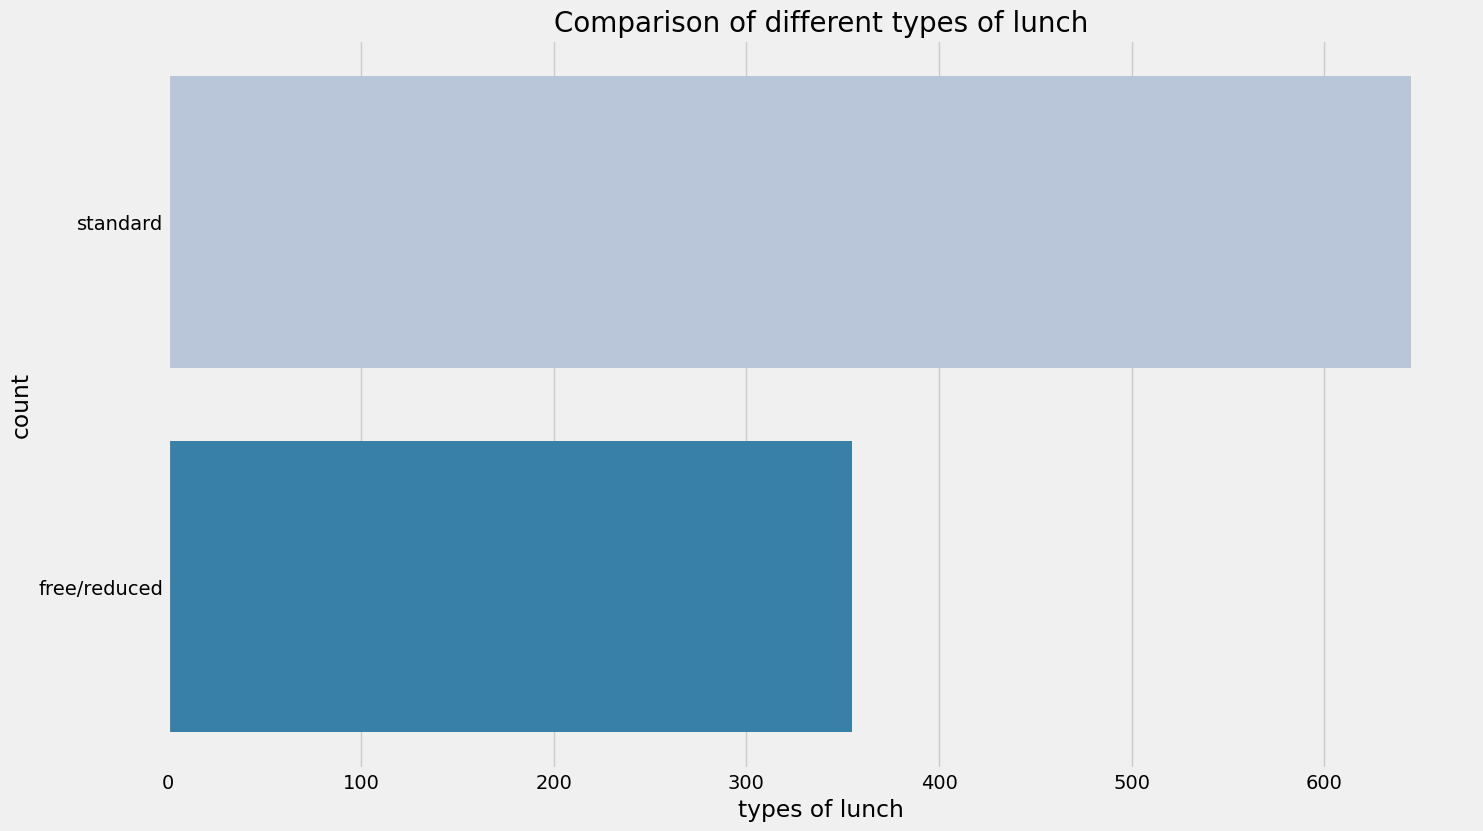

In [135]:
plt.rcParams['figure.figsize'] = (15, 9)
# sns.set_style('talk') 
sns.countplot(df['lunch'], palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

#### Insights 
- Students being served Standard lunch was more than free lunch

#### BIVARIATE ANALYSIS (  Is lunch type intake has any impact on student's performance ? )

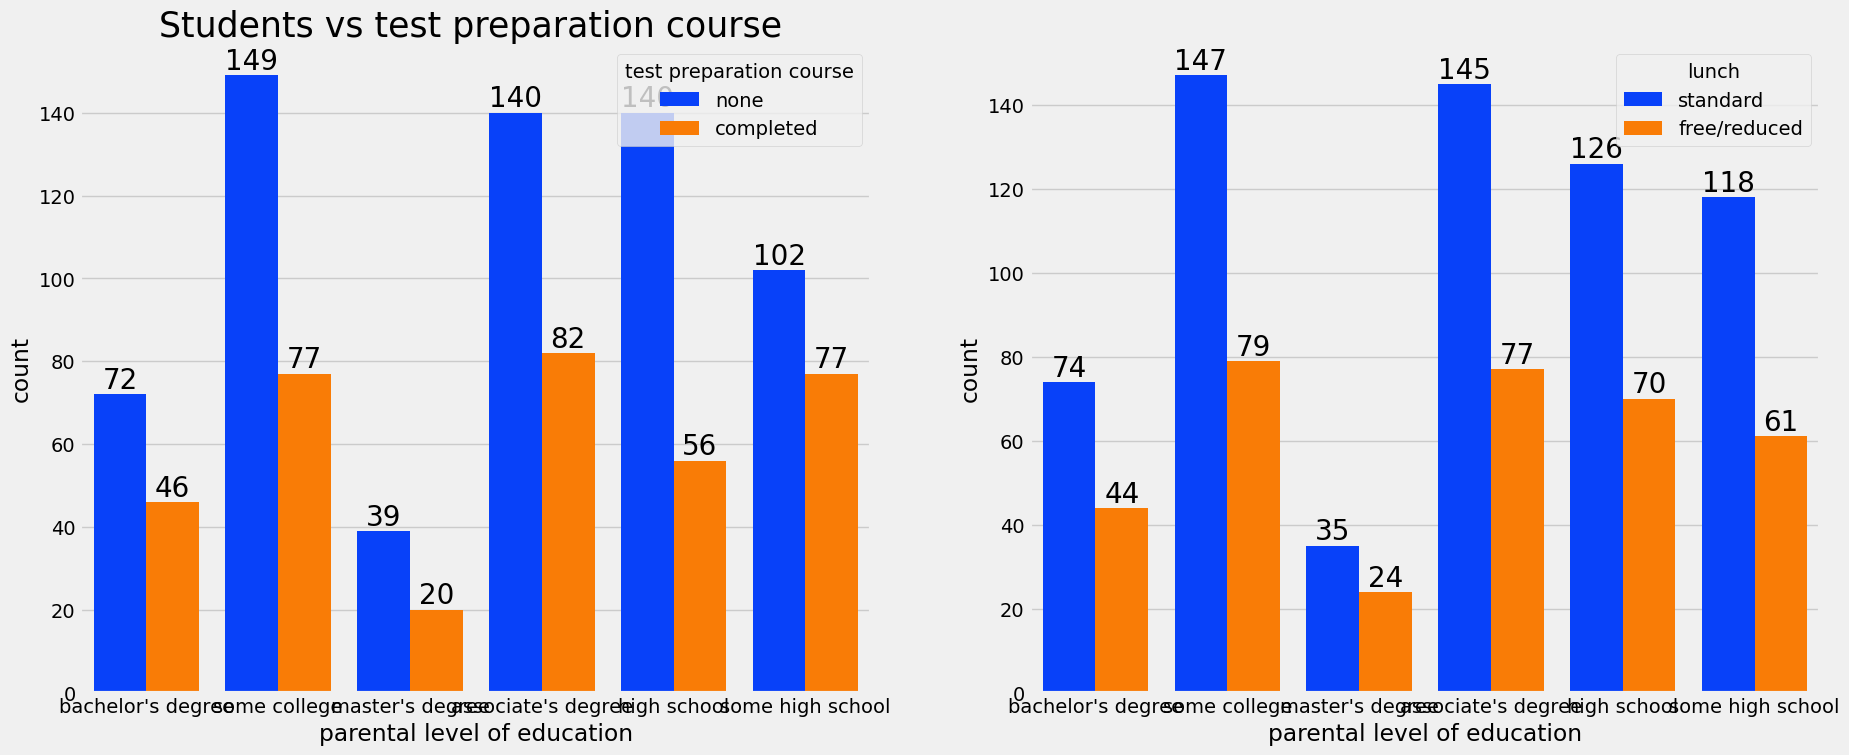

In [137]:
f,ax=plt.subplots(1,2,figsize=(20,8))
sns.countplot(
    x=df['parental level of education'],
    data=df,
    palette = 'bright',
    hue='test preparation course',
    saturation=0.95,
    ax=ax[0]
)
ax[0].set_title('Students vs test preparation course ',color='black',size=25)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)

sns.countplot(x=df['parental level of education'],data=df,palette = 'bright',hue='lunch',saturation=0.95,ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=20)

#### Insights 
- Students who get Standard Lunch tend to perform better than students who got free/reduced lunch

#### 4.4.5 TEST PREPARATION COURSE COLUMN 
- Which type of lunch is most common amoung students ?
- Is Test prepration course has any impact on student's performance ?

#### BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )

<Axes: xlabel='lunch', ylabel='writing score'>

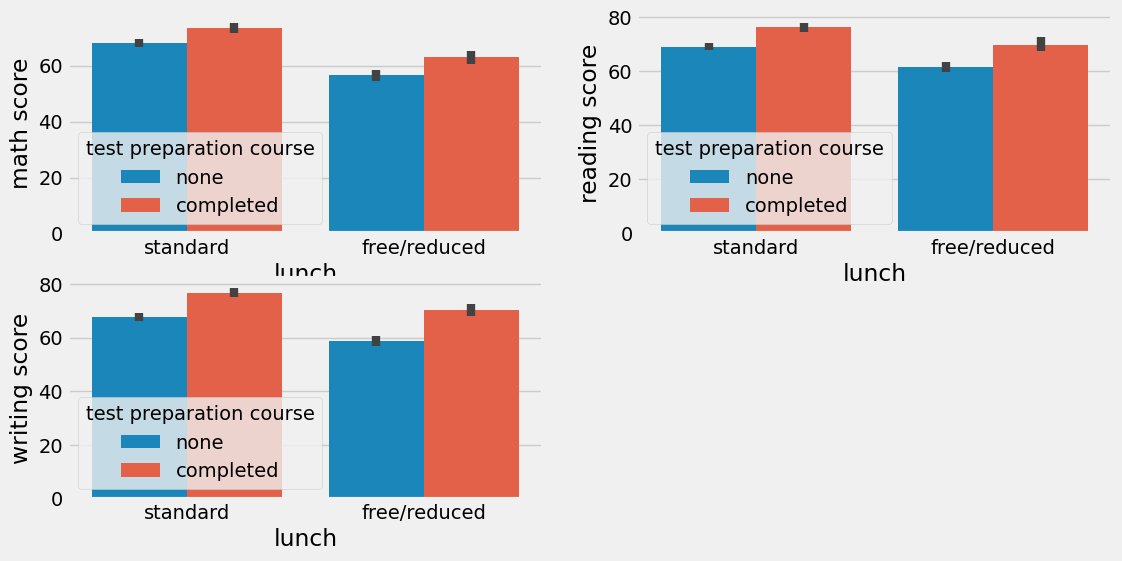

In [138]:
plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
sns.barplot (x=df['lunch'], y=df['math score'], hue=df['test preparation course'])
plt.subplot(2,2,2)
sns.barplot (x=df['lunch'], y=df['reading score'], hue=df['test preparation course'])
plt.subplot(2,2,3)
sns.barplot (x=df['lunch'], y=df['writing score'], hue=df['test preparation course'])

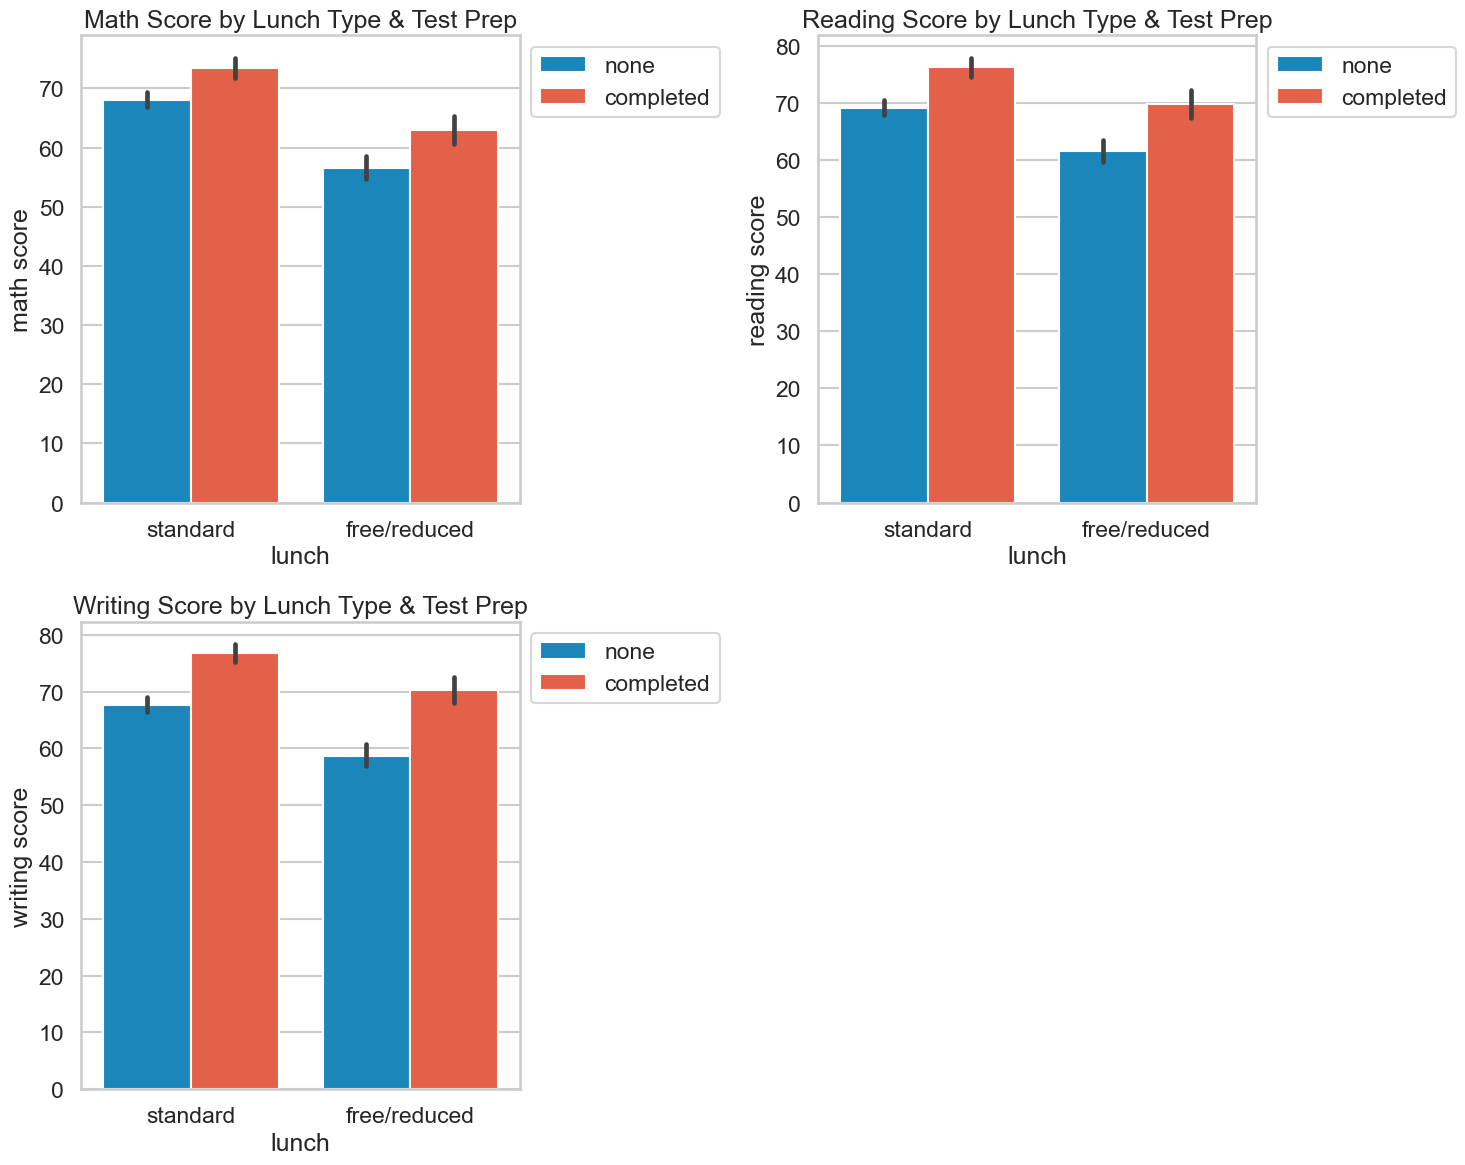

In [140]:
# Set style and context
sns.set_style('whitegrid')
sns.set_context('talk')

# Create figure with 3 subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Math score
sns.barplot(
    x='lunch',
    y='math score',
    hue='test preparation course',
    data=df,
    ax=axes[0,0]
)
axes[0,0].set_title('Math Score by Lunch Type & Test Prep')
axes[0,0].legend(loc='upper left', bbox_to_anchor=(1,1))  # move legend outside

# Reading score
sns.barplot(
    x='lunch',
    y='reading score',
    hue='test preparation course',
    data=df,
    ax=axes[0,1]
)
axes[0,1].set_title('Reading Score by Lunch Type & Test Prep')
axes[0,1].legend(loc='upper left', bbox_to_anchor=(1,1))  # move legend outside

# Writing score
sns.barplot(
    x='lunch',
    y='writing score',
    hue='test preparation course',
    data=df,
    ax=axes[1,0]
)
axes[1,0].set_title('Writing Score by Lunch Type & Test Prep')
axes[1,0].legend(loc='upper left', bbox_to_anchor=(1,1))  # move legend outside

# Remove empty subplot (bottom-right)
fig.delaxes(axes[1,1])

plt.tight_layout()
plt.show()

#### Insights  
- Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course

#### 4.4.6 CHECKING OUTLIERS

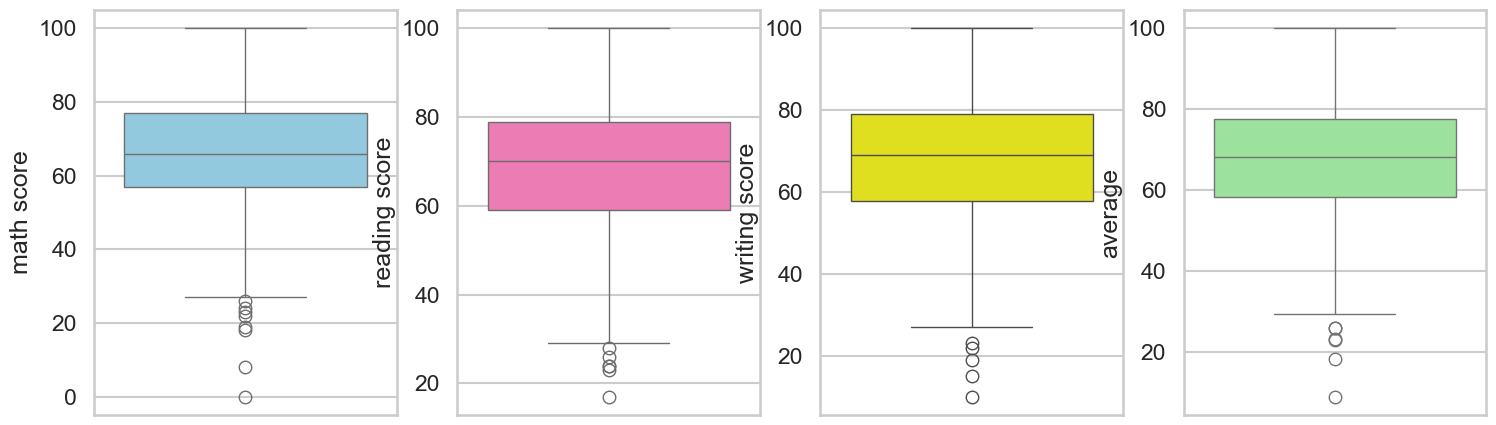

In [141]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average'],color='lightgreen')
plt.show()

#### 4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

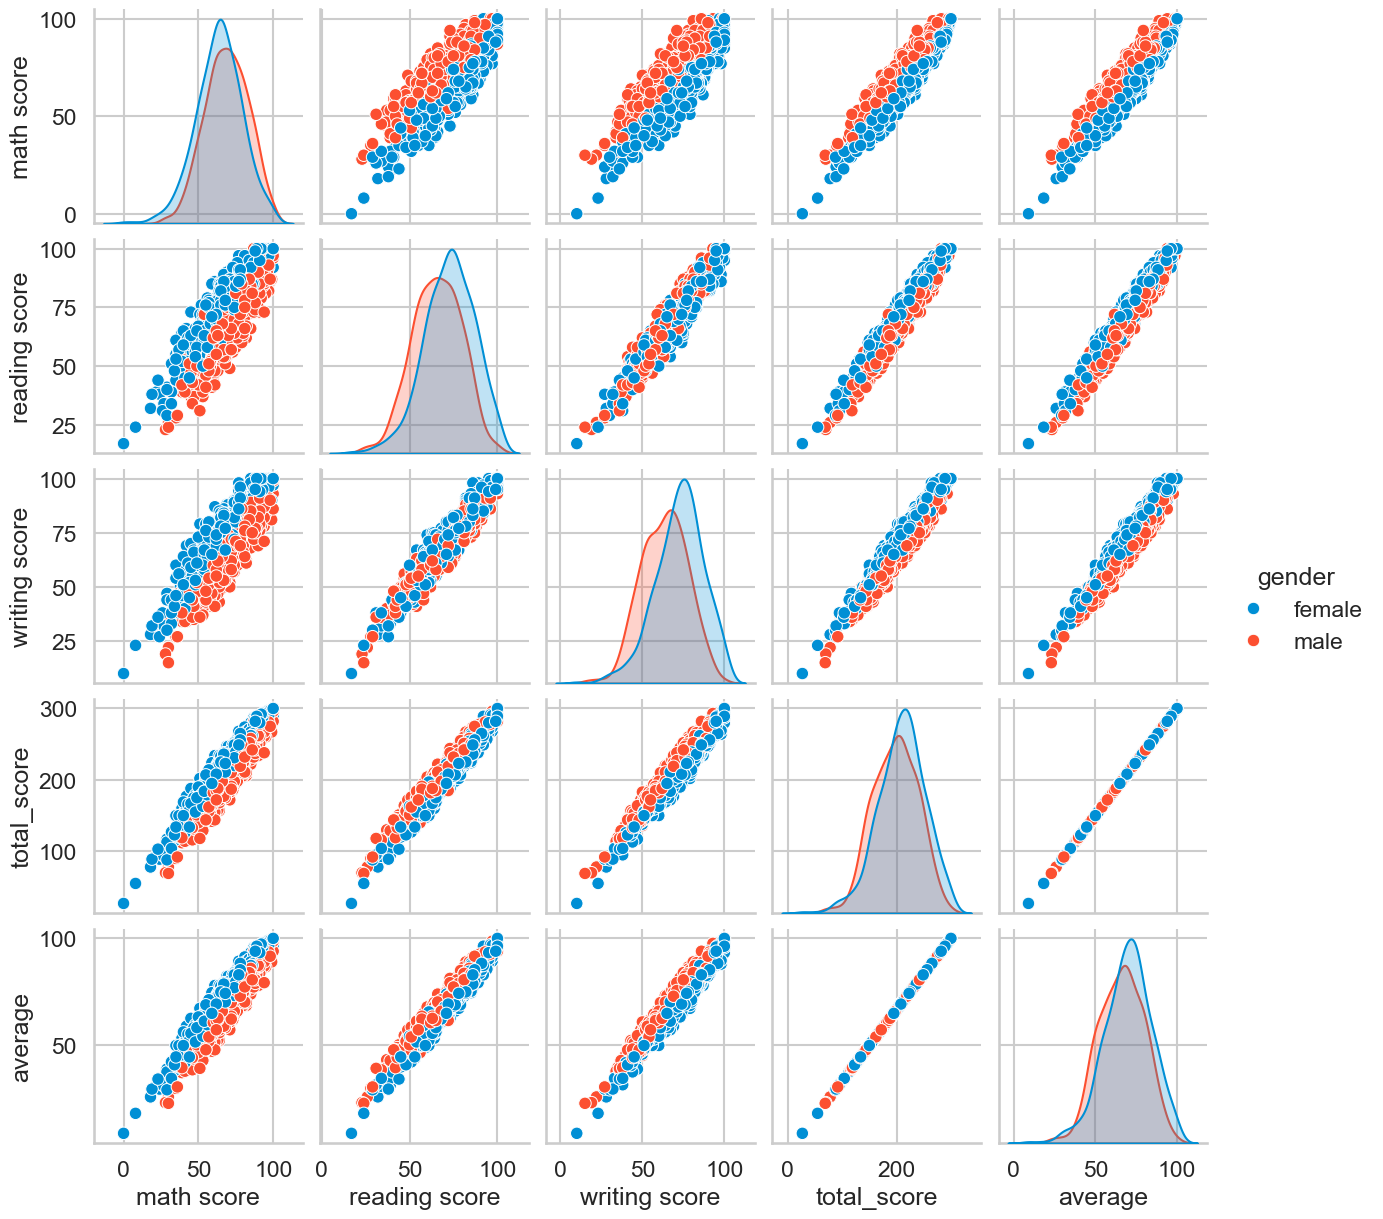

In [142]:
sns.pairplot(df,hue = 'gender')
plt.show()

#### Insights
- From the above plot it is clear that all the scores increase linearly with each other.

### 5. Conclusions
- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.

**Insights**
- Number of Male and Female students is almost equal
- Number students are greatest in Group C
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"